# Believability Analysis: All Participants vs. Participants Over 35

This notebook compares believability ratings between **all participants** and the **subset aged > 35**.

Each plot shows both groups side-by-side using the same axes for direct comparison.

- **Blue / solid** = All participants (N=50)
- **Orange / dashed** = Participants aged > 35


In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import ttest_rel, ttest_1samp
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='talk')

# colour palette 
COL_ALL  = '#2a6f97'   # blue  – all participants
COL_O35  = '#e07b39'   # orange – over-35 participants
ALPHA    = 0.75


## Load & Prepare Data

In [ ]:
DATA_PATH = Path('Cleaned.csv')
LLM_PATH  = Path('LLM_Labels.csv')

s22 = pd.read_csv(DATA_PATH)
llm = pd.read_csv(LLM_PATH).dropna(subset=['text'])

rating_cols = [c for c in s22.columns if 'Believability' in c]
meta_cols   = [c for c in s22.columns if c not in rating_cols]

melted = s22.melt(id_vars=meta_cols, value_vars=rating_cols,
                  var_name='column_header', value_name='believability_rating')
melted['text'] = melted['column_header'].str.split('\n').str[0].str.strip()

df = melted.merge(llm[['text', 'topic', 'condition', 'cue_type_final']], on='text', how='left')

analysis_cols = [
    'Participation Id', 'Age', 'Gender',
    'Main Source of Information',
    'Education Level (Completed/Current)',
    'Employement',
    'believability_rating', 'text',
    'topic', 'condition', 'cue_type_final',
]

df_all = df[analysis_cols].copy()
df_all = df_all.dropna(subset=['Participation Id', 'believability_rating',
                                'text', 'topic', 'condition', 'cue_type_final'])
df_all['Participation Id']    = df_all['Participation Id'].astype(int)
df_all['believability_rating'] = pd.to_numeric(df_all['believability_rating'], errors='coerce')
df_all['Age']                  = pd.to_numeric(df_all['Age'], errors='coerce')

for col, cats in [
    ('topic',          ['health', 'technology']),
    ('condition',      ['latent', 'recent', 'new']),
    ('cue_type_final', ['central', 'neutral', 'peripheral']),
]:
    df_all[col] = pd.Categorical(df_all[col], categories=cats, ordered=True)

#IQR outlier detection 
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series[(series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)]

#All partipicants: outlier check & removal 
pm_all = df_all.groupby('Participation Id')['believability_rating'].mean()
outliers_all = iqr_outliers(pm_all)
if len(outliers_all):
    print(f'All – removing {len(outliers_all)} outlier participant(s): {outliers_all.index.tolist()}')
    df_all = df_all[~df_all['Participation Id'].isin(outliers_all.index)].copy()
    for col, cats in [('topic', ['health','technology']), ('condition', ['latent','recent','new']),
                      ('cue_type_final', ['central','neutral','peripheral'])]:
        df_all[col] = pd.Categorical(df_all[col], categories=cats, ordered=True)
else:
    print('All – no outlier participants detected.')

#over-35 subset 
df_o35 = df_all[df_all['Age'] > 35].copy()

#over-35: outlier check & removal 
pm_o35 = df_o35.groupby('Participation Id')['believability_rating'].mean()
outliers_o35 = iqr_outliers(pm_o35)
if len(outliers_o35):
    print(f'Over-35 – removing {len(outliers_o35)} outlier participant(s): {outliers_o35.index.tolist()}')
    df_o35 = df_o35[~df_o35['Participation Id'].isin(outliers_o35.index)].copy()
    for col, cats in [('topic', ['health','technology']), ('condition', ['latent','recent','new']),
                      ('cue_type_final', ['central','neutral','peripheral'])]:
        df_o35[col] = pd.Categorical(df_o35[col], categories=cats, ordered=True)
else:
    print('Over-35 – no outlier participants detected.')

print(f'All participants  : {df_all["Participation Id"].nunique()} participants, {len(df_all)} rows')
print(f'Over-35 subset    : {df_o35["Participation Id"].nunique()} participants, {len(df_o35)} rows')


All – no outlier participants detected.
Over-35 – removing 1 outlier participant(s): [52]
All participants  : 50 participants, 1800 rows
Over-35 subset    : 12 participants, 432 rows


## 1 · Rating Distribution

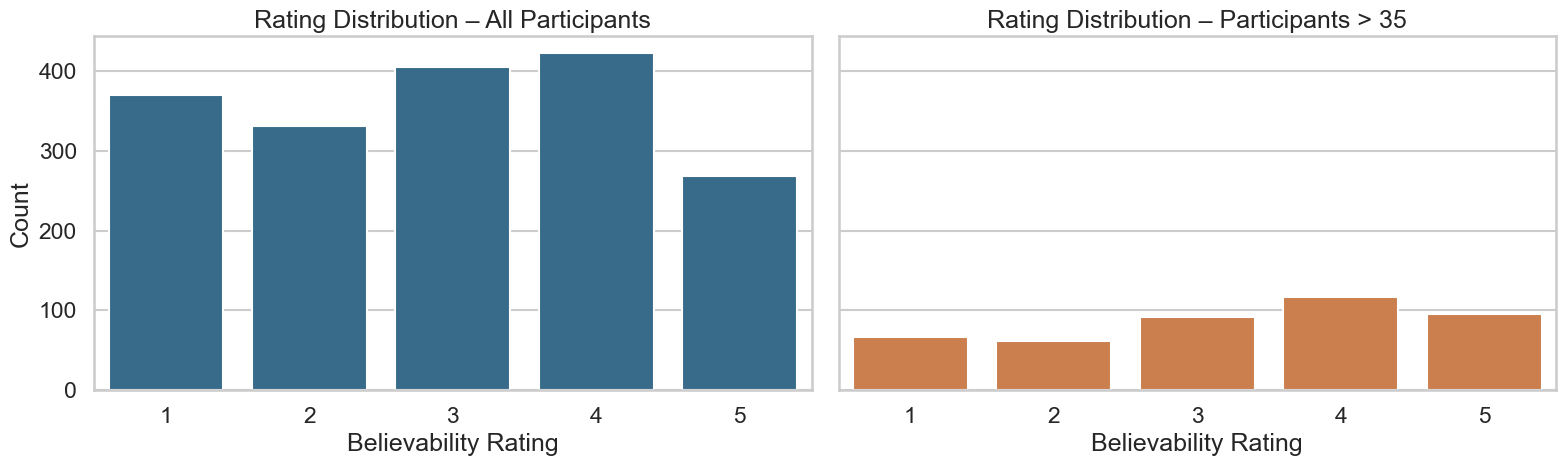

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, data, label, color in [
    (axes[0], df_all, 'All Participants',   COL_ALL),
    (axes[1], df_o35, 'Participants > 35',  COL_O35),
]:
    sns.countplot(data=data, x='believability_rating', color=color, ax=ax)
    ax.set_title(f'Rating Distribution – {label}')
    ax.set_xlabel('Believability Rating')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## 2 · Participant Mean Believability

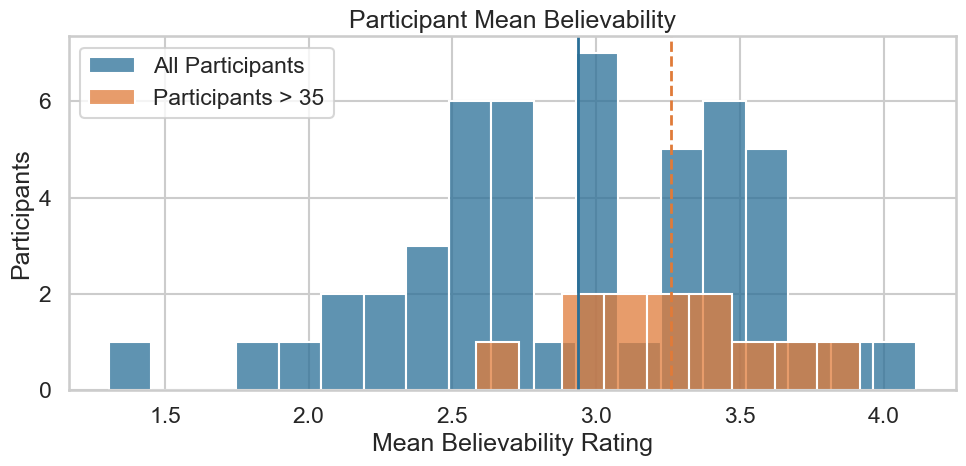

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

for data, label, color, ls in [
    (df_all, 'All Participants',  COL_ALL, '-'),
    (df_o35, 'Participants > 35', COL_O35, '--'),
]:
    pmeans = data.groupby('Participation Id')['believability_rating'].mean()
    sns.histplot(pmeans, binwidth=0.15, color=color, alpha=ALPHA,
                 label=label, ax=ax)
    ax.axvline(pmeans.mean(), color=color, linestyle=ls, linewidth=2)

ax.set_title('Participant Mean Believability')
ax.set_xlabel('Mean Believability Rating')
ax.set_ylabel('Participants')
ax.legend()
plt.tight_layout()
plt.show()


## 3 · Mean Rating by Topic

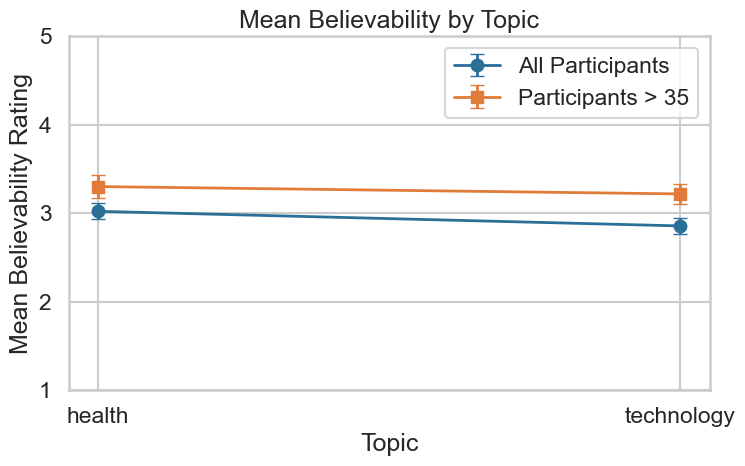

In [5]:
def cell_means(data, factors):
    return (
        data.groupby(['Participation Id'] + factors, observed=False)['believability_rating']
        .mean().reset_index()
        .rename(columns={'Participation Id': 'participant_id',
                         'believability_rating': 'mean_rating'})
    )

def mean_sem(data, factors):
    cells = cell_means(data, factors)
    return cells.groupby(factors, observed=False)['mean_rating'].agg(
        mean='mean', sem='sem').reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

for data, label, color, marker in [
    (df_all, 'All Participants',  COL_ALL, 'o'),
    (df_o35, 'Participants > 35', COL_O35, 's'),
]:
    s = mean_sem(data, ['topic'])
    ax.errorbar(s['topic'].astype(str), s['mean'],
                yerr=s['sem'], fmt=f'{marker}-',
                color=color, capsize=5, label=label, linewidth=2)

ax.set_title('Mean Believability by Topic')
ax.set_xlabel('Topic')
ax.set_ylabel('Mean Believability Rating')
ax.set_ylim(1, 5)
ax.legend()
plt.tight_layout()
plt.show()


## 4 · Mean Rating by Condition

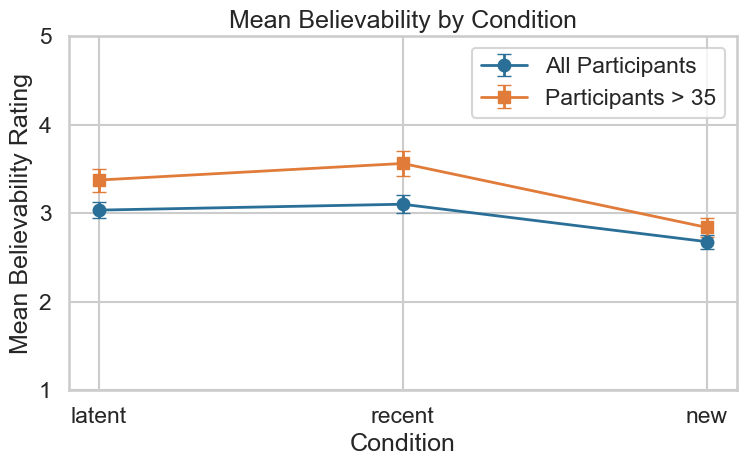

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for data, label, color, marker in [
    (df_all, 'All Participants',  COL_ALL, 'o'),
    (df_o35, 'Participants > 35', COL_O35, 's'),
]:
    s = mean_sem(data, ['condition'])
    ax.errorbar(s['condition'].astype(str), s['mean'],
                yerr=s['sem'], fmt=f'{marker}-',
                color=color, capsize=5, label=label, linewidth=2)

ax.set_title('Mean Believability by Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Mean Believability Rating')
ax.set_ylim(1, 5)
ax.legend()
plt.tight_layout()
plt.show()


## 5 · Mean Rating by Cue Type

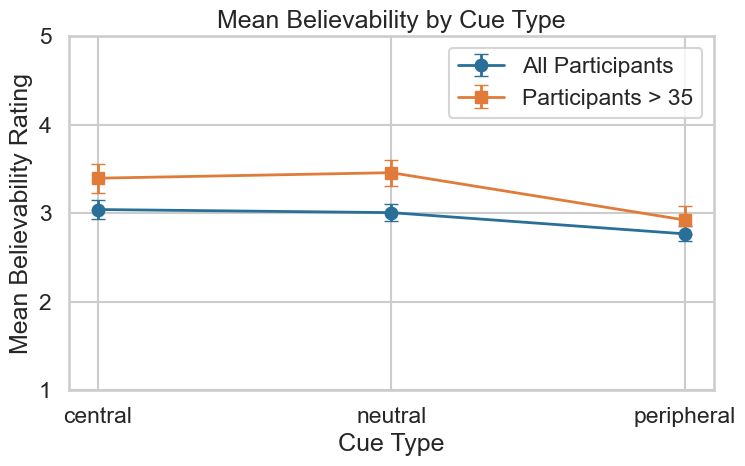

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for data, label, color, marker in [
    (df_all, 'All Participants',  COL_ALL, 'o'),
    (df_o35, 'Participants > 35', COL_O35, 's'),
]:
    s = mean_sem(data, ['cue_type_final'])
    ax.errorbar(s['cue_type_final'].astype(str), s['mean'],
                yerr=s['sem'], fmt=f'{marker}-',
                color=color, capsize=5, label=label, linewidth=2)

ax.set_title('Mean Believability by Cue Type')
ax.set_xlabel('Cue Type')
ax.set_ylabel('Mean Believability Rating')
ax.set_ylim(1, 5)
ax.legend()
plt.tight_layout()
plt.show()


## 6 · Topic × Condition Interaction

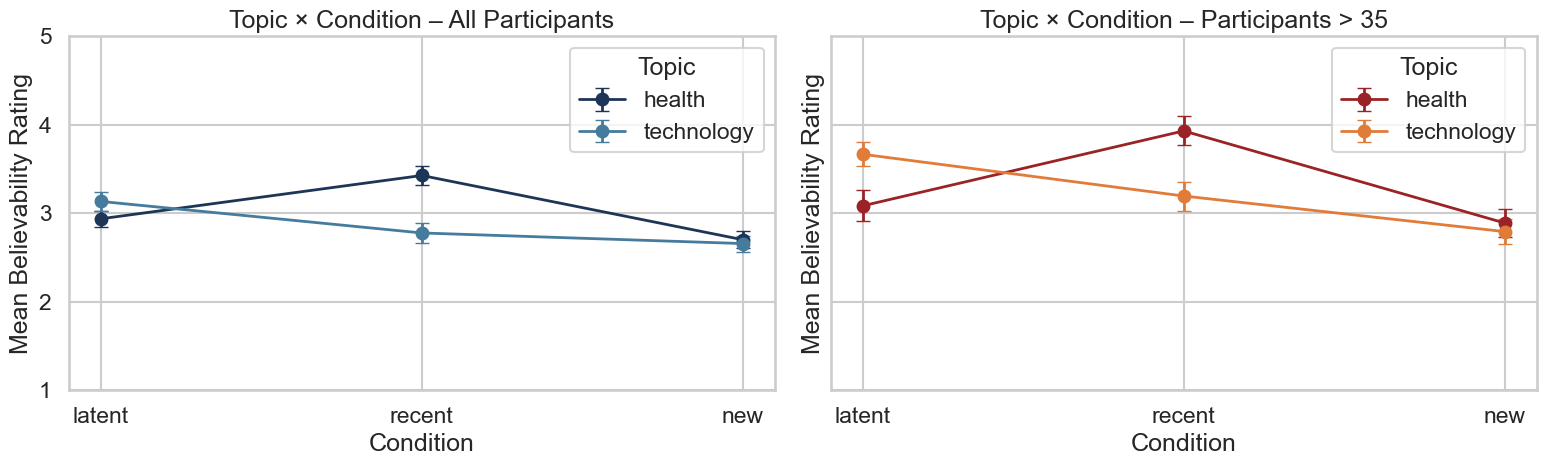

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, data, label, palette in [
    (axes[0], df_all, 'All Participants',  ['#1d3557', '#457b9d']),
    (axes[1], df_o35, 'Participants > 35', ['#9b2226', '#e07b39']),
]:
    s = mean_sem(data, ['topic', 'condition'])
    for i, topic in enumerate(s['topic'].cat.categories):
        sub = s[s['topic'] == topic]
        ax.errorbar(sub['condition'].astype(str), sub['mean'],
                    yerr=sub['sem'], fmt='o-',
                    color=palette[i], capsize=5,
                    label=topic, linewidth=2)
    ax.set_title(f'Topic × Condition – {label}')
    ax.set_xlabel('Condition')
    ax.set_ylabel('Mean Believability Rating')
    ax.set_ylim(1, 5)
    ax.legend(title='Topic')

plt.tight_layout()
plt.show()


## 7 · Topic × Cue Type Interaction

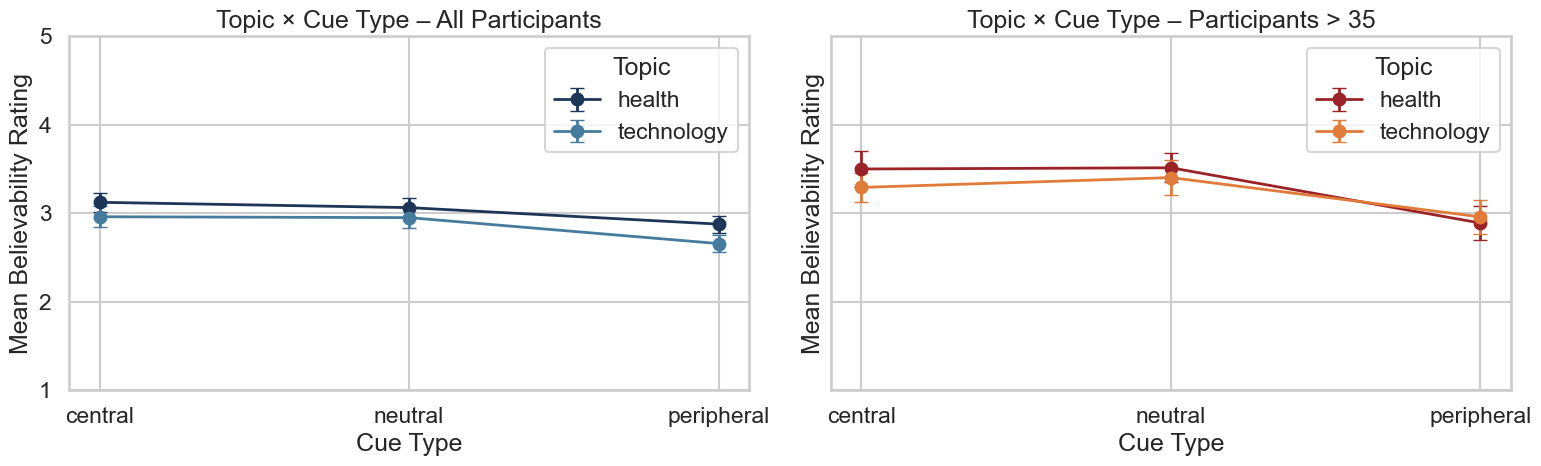

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, data, label, palette in [
    (axes[0], df_all, 'All Participants',  ['#1d3557', '#457b9d']),
    (axes[1], df_o35, 'Participants > 35', ['#9b2226', '#e07b39']),
]:
    s = mean_sem(data, ['topic', 'cue_type_final'])
    for i, topic in enumerate(s['topic'].cat.categories):
        sub = s[s['topic'] == topic]
        ax.errorbar(sub['cue_type_final'].astype(str), sub['mean'],
                    yerr=sub['sem'], fmt='o-',
                    color=palette[i], capsize=5,
                    label=topic, linewidth=2)
    ax.set_title(f'Topic × Cue Type – {label}')
    ax.set_xlabel('Cue Type')
    ax.set_ylabel('Mean Believability Rating')
    ax.set_ylim(1, 5)
    ax.legend(title='Topic')

plt.tight_layout()
plt.show()


## 8 · Condition × Cue Type Interaction

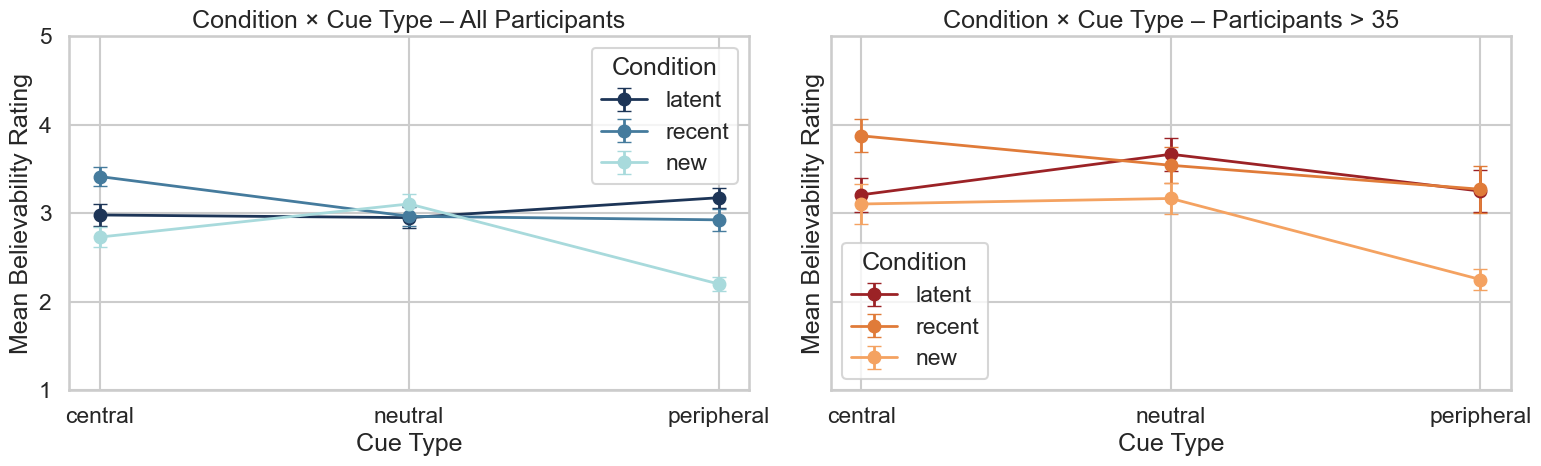

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, data, label, palette in [
    (axes[0], df_all, 'All Participants',  ['#1d3557', '#457b9d', '#a8dadc']),
    (axes[1], df_o35, 'Participants > 35', ['#9b2226', '#e07b39', '#f4a261']),
]:
    s = mean_sem(data, ['condition', 'cue_type_final'])
    for i, cond in enumerate(s['condition'].cat.categories):
        sub = s[s['condition'] == cond]
        ax.errorbar(sub['cue_type_final'].astype(str), sub['mean'],
                    yerr=sub['sem'], fmt='o-',
                    color=palette[i], capsize=5,
                    label=cond, linewidth=2)
    ax.set_title(f'Condition × Cue Type – {label}')
    ax.set_xlabel('Cue Type')
    ax.set_ylabel('Mean Believability Rating')
    ax.set_ylim(1, 5)
    ax.legend(title='Condition')

plt.tight_layout()
plt.show()


## 9 · Boxplots by Factor (All vs. Over-35)

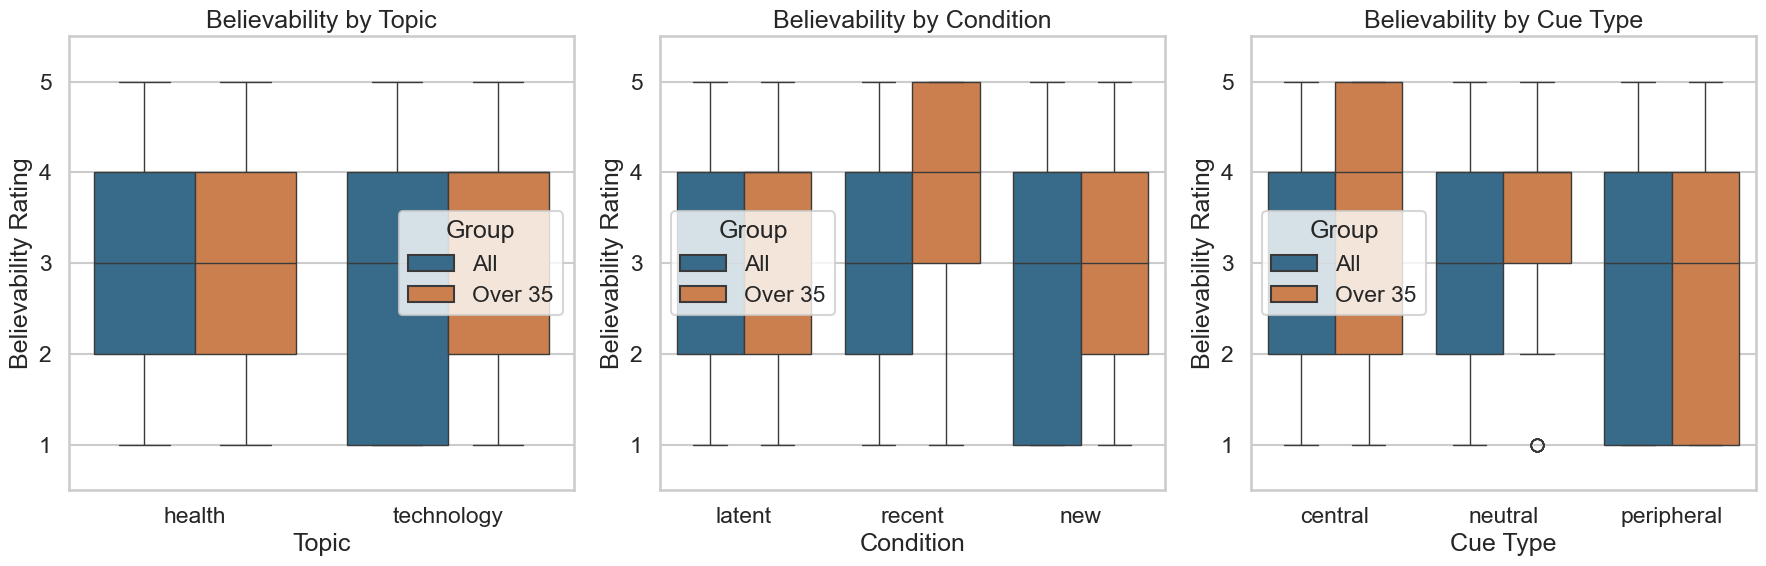

In [11]:
# Add a group label so we can use hue
df_all_tagged = df_all.copy(); df_all_tagged['Group'] = 'All'
df_o35_tagged = df_o35.copy(); df_o35_tagged['Group'] = 'Over 35'
combined = pd.concat([df_all_tagged, df_o35_tagged], ignore_index=True)

palette = {'All': COL_ALL, 'Over 35': COL_O35}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, factor, title in [
    (axes[0], 'topic',          'Topic'),
    (axes[1], 'condition',      'Condition'),
    (axes[2], 'cue_type_final', 'Cue Type'),
]:
    sns.boxplot(data=combined, x=factor, y='believability_rating',
                hue='Group', palette=palette, ax=ax)
    ax.set_title(f'Believability by {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Believability Rating')
    ax.set_ylim(0.5, 5.5)
    ax.legend(title='Group')

plt.tight_layout()
plt.show()


## 10 · Violin Plots by Factor (All vs. Over-35)

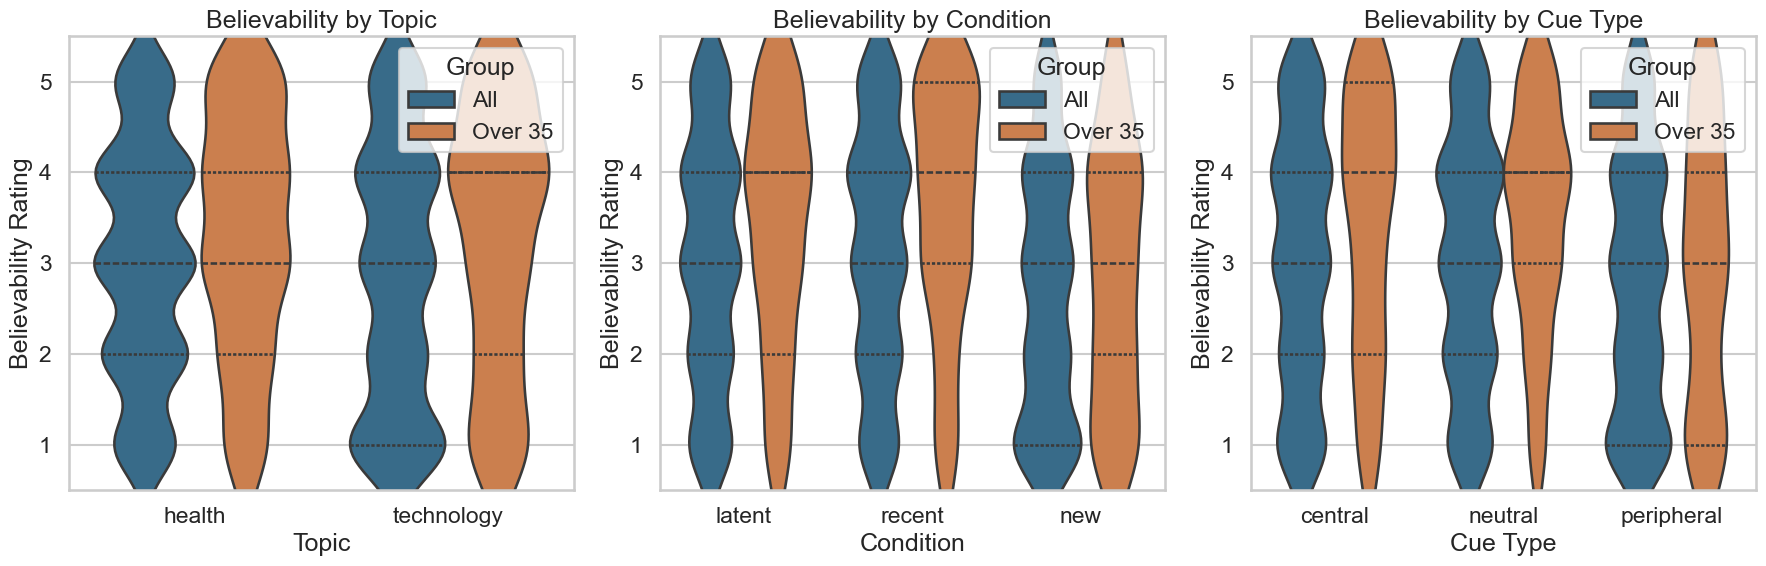

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, factor, title in [
    (axes[0], 'topic',          'Topic'),
    (axes[1], 'condition',      'Condition'),
    (axes[2], 'cue_type_final', 'Cue Type'),
]:
    sns.violinplot(data=combined, x=factor, y='believability_rating',
                   hue='Group', palette=palette, split=False,
                   inner='quartile', ax=ax)
    ax.set_title(f'Believability by {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Believability Rating')
    ax.set_ylim(0.5, 5.5)
    ax.legend(title='Group')

plt.tight_layout()
plt.show()


## 11 · Topic × Condition × Cue Type (Three-Way Interaction)

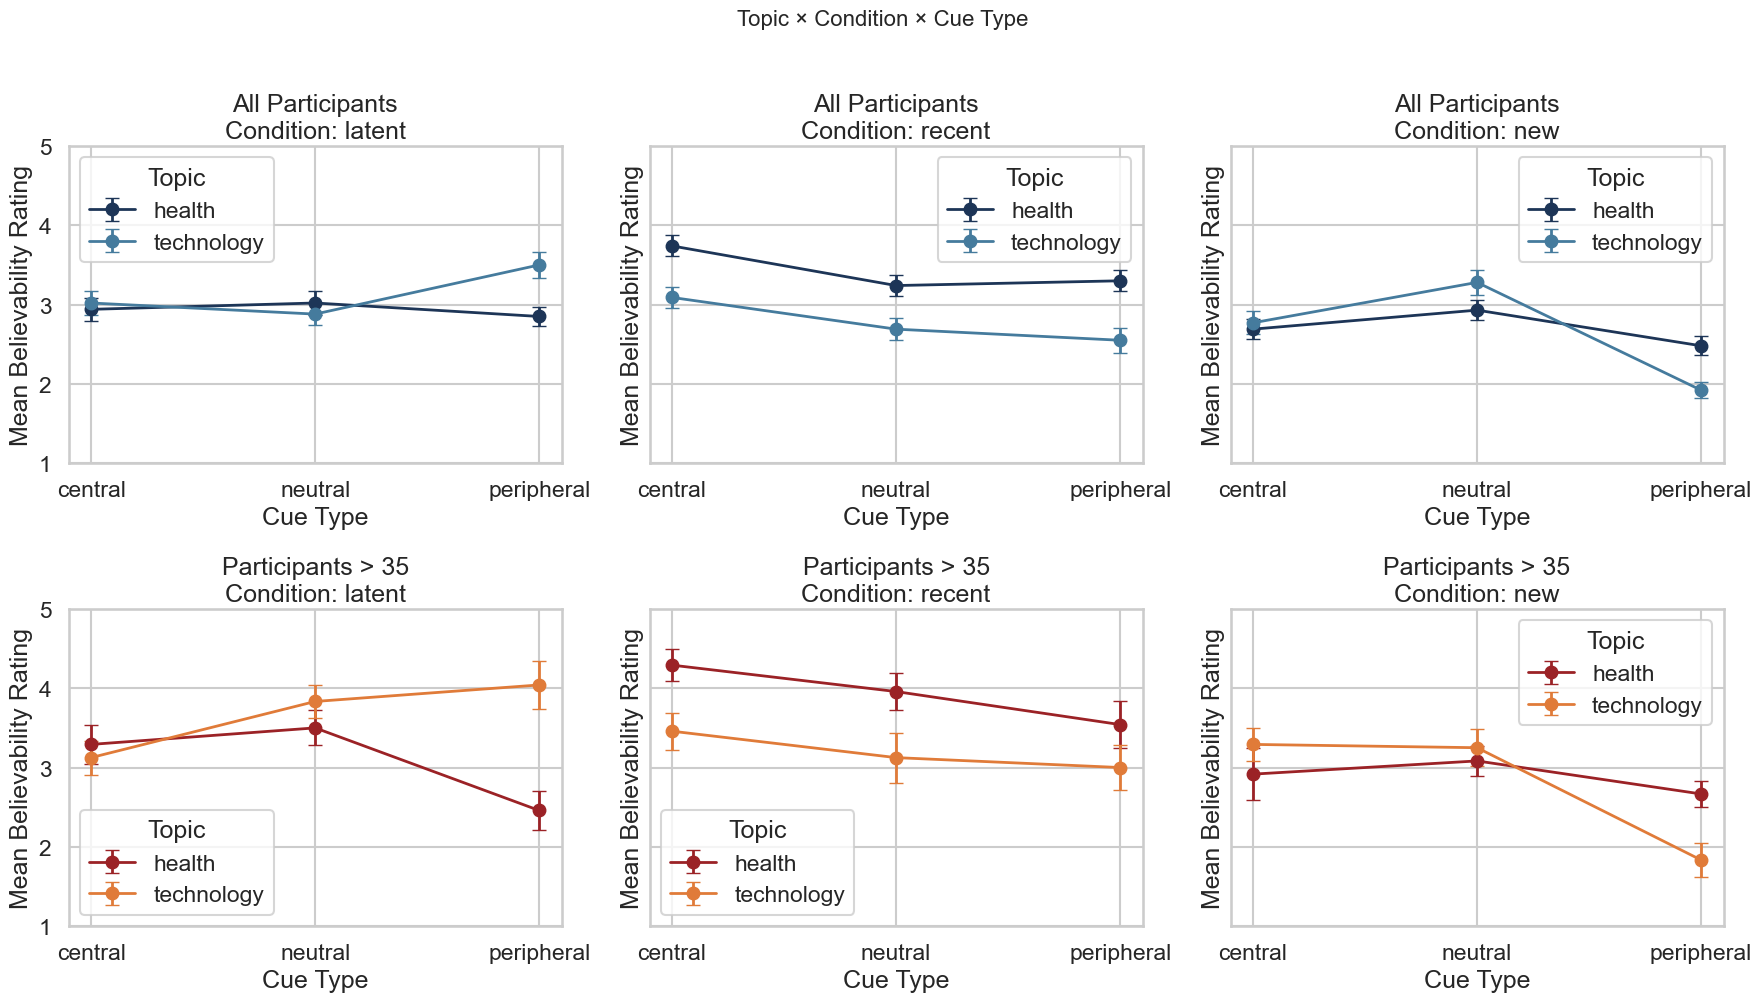

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

topics = list(df_all['topic'].cat.categories)
conditions = list(df_all['condition'].cat.categories)

for col_idx, condition in enumerate(conditions):
    for row_idx, (data, label, palette) in enumerate([
        (df_all, 'All Participants',  ['#1d3557', '#457b9d']),
        (df_o35, 'Participants > 35', ['#9b2226', '#e07b39']),
    ]):
        ax = axes[row_idx][col_idx]
        sub_data = data[data['condition'] == condition]
        s = mean_sem(sub_data, ['topic', 'cue_type_final'])
        for i, topic in enumerate(s['topic'].cat.categories):
            sub = s[s['topic'] == topic]
            ax.errorbar(sub['cue_type_final'].astype(str), sub['mean'],
                        yerr=sub['sem'], fmt='o-',
                        color=palette[i], capsize=5,
                        label=topic, linewidth=2)
        ax.set_title(f'{label}\nCondition: {condition}')
        ax.set_xlabel('Cue Type')
        ax.set_ylabel('Mean Believability Rating')
        ax.set_ylim(1, 5)
        ax.legend(title='Topic')

plt.suptitle('Topic × Condition × Cue Type', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 12 · Descriptive Summary Comparison

In [14]:
def describe_group(data, label):
    return pd.Series({
        'group':                  label,
        'n_participants':         data['Participation Id'].nunique(),
        'n_ratings':              len(data),
        'mean_rating':            data['believability_rating'].mean(),
        'sd_rating':              data['believability_rating'].std(),
        'median_rating':          data['believability_rating'].median(),
        'prop_not_believable_1_2': (data['believability_rating'] <= 2).mean(),
        'prop_neutral_3':          (data['believability_rating'] == 3).mean(),
        'prop_believable_4_5':     (data['believability_rating'] >= 4).mean(),
    })

summary = pd.DataFrame([
    describe_group(df_all, 'All Participants'),
    describe_group(df_o35, 'Participants > 35'),
]).set_index('group')

display(summary.round(4))


,n_participants,n_ratings,mean_rating,sd_rating,median_rating,prop_not_believable_1_2,prop_neutral_3,prop_believable_4_5
group,,,,,,,,
All Participants,50,1800,2.9383,1.3552,3.0,0.3900,0.2256,0.3844
Participants > 35,12,432,3.2593,1.3598,3.0,0.2963,0.2130,0.4907
